In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = '/Users/qiaoqiao/Desktop/Documents/Company and online projects/Mobile Games A:B testing project/cookie_cats.csv'

df = pd.read_csv(file_path)

df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
#check null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
#check duplicates
df['userid'].duplicated().sum()

0

In [5]:
#check other potential issues
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [6]:
(df['sum_gamerounds'] < 0).sum()

0

In [7]:
df['retention_1'] = df['retention_1'].astype(int)
df['retention_7'] = df['retention_7'].astype(int)
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,0,0
1,337,gate_30,38,1,0
2,377,gate_40,165,1,0
3,483,gate_40,1,0,0
4,488,gate_40,179,1,1


In [8]:
#create group summary for a general review
group_summary = df.groupby('version').agg(users=('userid', 'count'),
                                          avg_game_rounds=('sum_gamerounds', 'mean'),
                                          day_1_retained_users=('retention_1', 'sum'),
                                          day_1_retention_rate=('retention_1', 'mean'),
                                          day_7_retained_users=('retention_7', 'sum'),
                                          day_7_retention_rate=('retention_7', 'mean')).reset_index()
group_summary

,version,users,avg_game_rounds,day_1_retained_users,day_1_retention_rate,day_7_retained_users,day_7_retention_rate
0,gate_30,44700,52.456264,20034,0.448188,8502,0.190201
1,gate_40,45489,51.298776,20119,0.442283,8279,0.182000


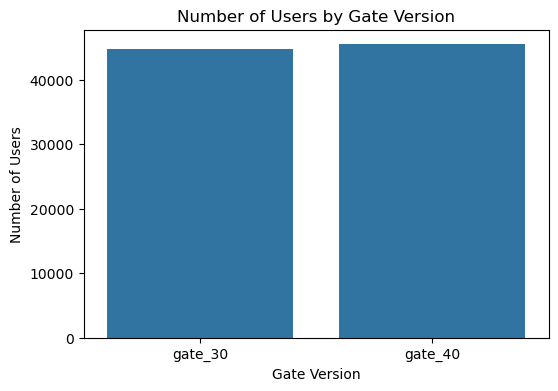

In [9]:
#bar chart of number of users and version
plt.figure(figsize=(6, 4))

sns.barplot(data=group_summary, x='version', y='users')

plt.title('Number of Users by Gate Version')
plt.xlabel('Gate Version')
plt.ylabel('Number of Users')

plt.show()

In [10]:
#melt group summary to build charts for retention rate
retention_rate_summary = group_summary.melt(id_vars='version',
                                            value_vars=['day_1_retention_rate', 'day_7_retention_rate'],
                                            var_name='days',
                                            value_name='retention_rate')
retention_rate_summary['days'] = retention_rate_summary['days'].replace({'day_1_retention_rate': 'Day 1',
                                                                         'day_7_retention_rate': 'Day 7'})
retention_rate_summary

,version,days,retention_rate
0,gate_30,Day 1,0.448188
1,gate_40,Day 1,0.442283
2,gate_30,Day 7,0.190201
3,gate_40,Day 7,0.182000


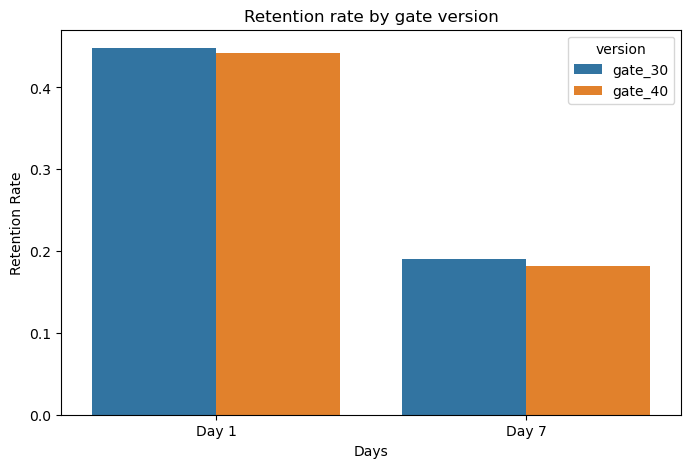

In [11]:
#bar plot of retention rate by gate version
plt.figure(figsize=(8,5))

sns.barplot(data=retention_rate_summary, x='days', y='retention_rate', hue='version')

plt.title('Retention rate by gate version')
plt.xlabel('Days')
plt.ylabel('Retention Rate')

plt.show()

In [12]:
#melt group summary to build charts for retented users
retained_users_summary = group_summary.melt(id_vars='version',
                                            value_vars=['day_1_retained_users', 'day_7_retained_users'],
                                            var_name='days',
                                            value_name='retained_users')
retained_users_summary['days'] = retained_users_summary['days'].replace({'day_1_retained_users': 'Day 1',
                                                                         'day_7_retained_users': 'Day 7'})
retained_users_summary

,version,days,retained_users
0,gate_30,Day 1,20034
1,gate_40,Day 1,20119
2,gate_30,Day 7,8502
3,gate_40,Day 7,8279


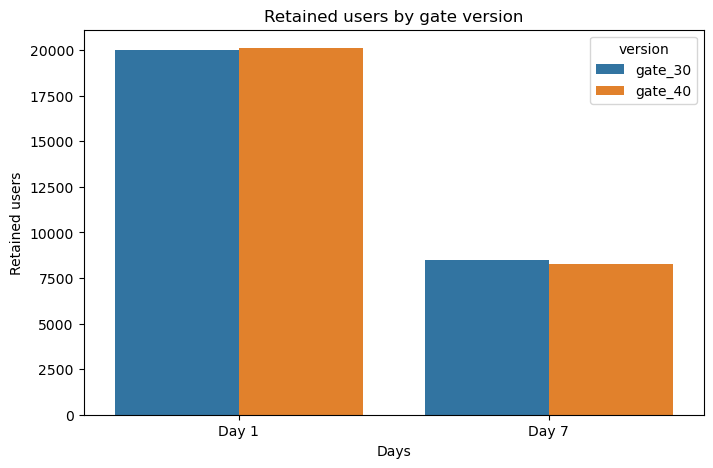

In [13]:
#bar plot of retented users by gate version
plt.figure(figsize=(8,5))

sns.barplot(data=retained_users_summary, x='days', y='retained_users', hue='version')

plt.title('Retained users by gate version')
plt.xlabel('Days')
plt.ylabel('Retained users')

plt.show()

In [14]:
#A/B testing for retention rate on Day1 and Day7 for different gate versions
#for day 1
#H0: day-1 retention rate is the same between gate 30 and gate 40
#Ha: day-1 retention rate is different between gate 30 and gate 40
from statsmodels.stats.proportion import proportions_ztest

day_1_retained = [df[df['version'] == 'gate_30']['retention_1'].sum(),
                  df[df['version'] == 'gate_40']['retention_1'].sum()]
day_1_users = [df[df['version'] == 'gate_30']['userid'].nunique(),
               df[df['version'] == 'gate_40']['userid'].nunique()]

z_stat_day1, p_value_day1 = proportions_ztest(count = day_1_retained, 
                                              nobs = day_1_users,
                                              alternative = 'two-sided')

print('Day 1 Retention A/B Test')
print('Z-statistic:', z_stat_day1)
print('P-value:', p_value_day1)

Day 1 Retention A/B Test
Z-statistic: 1.7840862247974725
P-value: 0.07440965529691913


In [15]:
#for day 7
#H0: day-7 retention rate is the same between gate 30 and gate 40
#Ha: day-7 retention rate is different between gate 30 and gate 40

day_7_retained = [df[df['version'] == 'gate_30']['retention_7'].sum(),
                  df[df['version'] == 'gate_40']['retention_7'].sum()]
day_7_users = [df[df['version'] == 'gate_30']['userid'].nunique(),
               df[df['version'] == 'gate_40']['userid'].nunique()]

z_stat_day7, p_value_day7 = proportions_ztest(count = day_7_retained, 
                                              nobs = day_7_users,
                                              alternative = 'two-sided')

print('Day 1 Retention A/B Test')
print('Z-statistic:', z_stat_day7)
print('P-value:', p_value_day7)

Day 1 Retention A/B Test
Z-statistic: 3.164358912748191
P-value: 0.001554249975614329


In [16]:
alpha = 0.05

if p_value_day1 < alpha:
    print('Day 1 result: Reject the null hypothesis.')
else:
    print('Day 1 result: Fail to reject the null hypothesis.')

if p_value_day7 < alpha:
    print('Day 7 result: Reject the null hypothesis.')
else:
    print('Day 7 result: Fail to reject the null hypothesis.')

Day 1 result: Fail to reject the null hypothesis.
Day 7 result: Reject the null hypothesis.


In [17]:
#on day 1 after installation, gate version doesn't have a significant effect on retention rate, but it has an effect on day 7(long-term effect)
#now we need to figure our if moving gate to lvl40 has improved retention rate

In [18]:
group_summary

,version,users,avg_game_rounds,day_1_retained_users,day_1_retention_rate,day_7_retained_users,day_7_retention_rate
0,gate_30,44700,52.456264,20034,0.448188,8502,0.190201
1,gate_40,45489,51.298776,20119,0.442283,8279,0.182000


In [19]:
#gate30 has higher retention rate than gate40 on day 7, and the difference is statistically significant.
#this suggests that keeping the gate at level 30 may be better for long-term player retention than moving it to level 40.
#although the difference in day-7 retention is statistically significant, 
#the size of the difference should also be considered before making a business decision.

In [20]:
#calculate absolute and relative retention rate increase
gate_30 = group_summary[group_summary['version'] == 'gate_30'].iloc[0]
gate_40 = group_summary[group_summary['version'] == 'gate_40'].iloc[0]

absolute_lift = gate_30['day_7_retention_rate'] - gate_40['day_7_retention_rate']
relative_lift = absolute_lift / gate_40['day_7_retention_rate']

print('Absolute lift:', absolute_lift)
print('Relative lift:', relative_lift)

Absolute lift: 0.008201298315205913
Relative lift: 0.04506206776910276


In [21]:
#gate_30 is higher by 0.82 percentage points
#gate_30 has about 4.5% higher day-7 retention relative to gate_40

In [22]:
#after analyzing retention, I examined total game rounds to understand whether gate placement also affected player engagement. 
#since game rounds are a behavioral count metric and may be highly skewed, I first explored the distribution before choosing an appropriate statistical test.

In [23]:
#general game rounds description
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

In [24]:
#game rounds group summary
game_rounds_summary = df.groupby('version')['sum_gamerounds'].agg(users='count',
                                                                  avg_game_rounds='mean',
                                                                  median_game_rounds='median',
                                                                  min_game_rounds='min',
                                                                  max_game_rounds='max').reset_index()

game_rounds_summary

,version,users,avg_game_rounds,median_game_rounds,min_game_rounds,max_game_rounds
0,gate_30,44700,52.456264,17.0,0,49854
1,gate_40,45489,51.298776,16.0,0,2640


In [25]:
#to further investigate outliers
rounds_percentile = df.groupby('version')['sum_gamerounds'].quantile([0.25,0.5,0.75,0.9,0.95,0.99])
rounds_percentile

version      
gate_30  0.25      5.00
         0.50     17.00
         0.75     50.00
         0.90    135.00
         0.95    222.00
         0.99    493.00
gate_40  0.25      5.00
         0.50     16.00
         0.75     52.00
         0.90    134.00
         0.95    220.00
         0.99    492.12
Name: sum_gamerounds, dtype: float64

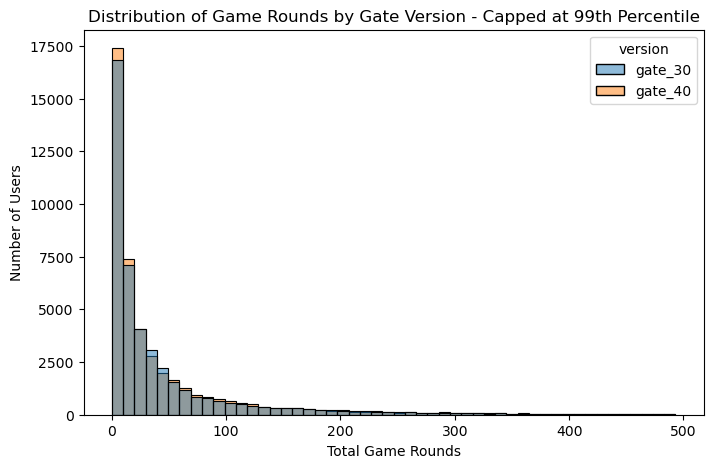

In [26]:
#histogram of game rounds after capped at 99th percentile range
rounds_99 = df['sum_gamerounds'].quantile(0.99)

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df['sum_gamerounds'] <= rounds_99],
    x='sum_gamerounds',
    hue='version',
    bins=50
)

plt.title('Distribution of Game Rounds by Gate Version - Capped at 99th Percentile')
plt.xlabel('Total Game Rounds')
plt.ylabel('Number of Users')

plt.show()

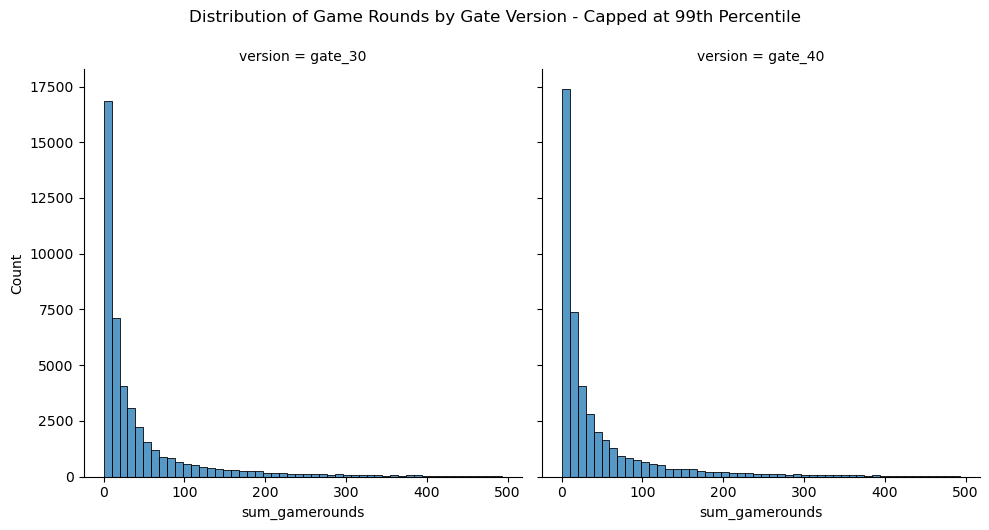

In [27]:
#distribution of game rounds with gate version separated
rounds_99 = df['sum_gamerounds'].quantile(0.99)

sns.displot(
    data=df[df['sum_gamerounds'] <= rounds_99],
    x='sum_gamerounds',
    col='version',
    bins=50
)

plt.suptitle(
    'Distribution of Game Rounds by Gate Version - Capped at 99th Percentile',
    y=1.05
)

plt.show()

In [28]:
#output 10 extreme cases in game rounds
df.sort_values('sum_gamerounds', ascending=False).head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,0,1
7912,871500,gate_30,2961,1,1
29417,3271615,gate_40,2640,1,0
43671,4832608,gate_30,2438,1,1
48188,5346171,gate_40,2294,1,1
46344,5133952,gate_30,2251,1,1
87007,9640085,gate_30,2156,1,1
36933,4090246,gate_40,2124,1,1
88328,9791599,gate_40,2063,1,1
6536,725080,gate_40,2015,1,1


In [29]:
#perform the group summary again without the extreme case
game_rounds_summary = df[df['sum_gamerounds'] < 49854].groupby('version')['sum_gamerounds'].agg(users='count',
                                                                  avg_game_rounds='mean',
                                                                  median_game_rounds='median',
                                                                  min_game_rounds='min',
                                                                  max_game_rounds='max').reset_index()

game_rounds_summary

,version,users,avg_game_rounds,median_game_rounds,min_game_rounds,max_game_rounds
0,gate_30,44699,51.342111,17.0,0,2961
1,gate_40,45489,51.298776,16.0,0,2640


In [30]:
#after excluding the single extreme outlier with 49,854 game rounds, the average game rounds for gate_30 and gate_40 became much closer. 
#this suggests that the original difference in average game rounds was largely driven by one unusually active user rather than a broad engagement difference between the two groups.

In [31]:
#game rounds A/B testing
#Question to answer: Does gate placement affect engagement, measured by total game rounds?
#H0: The distribution of sum_gamerounds is the same for gate_30 and gate_40.
#H1: The distribution of sum_gamerounds differs between gate_30 and gate_40.

In [32]:
#mann whitney u test for game rounds and gate version
from scipy.stats import mannwhitneyu

gate_30_rounds = df[df['version'] == 'gate_30']['sum_gamerounds']
gate_40_roudns = df[df['version'] == 'gate_40']['sum_gamerounds']

u_statistic, u_p_value = mannwhitneyu(gate_30_rounds, gate_40_roudns, alternative='two-sided')

print('Mann-Whitney U Test for Game Rounds')
print('U statistic:', u_statistic)
print('P-value:', u_p_value)

Mann-Whitney U Test for Game Rounds
U statistic: 1024331250.5
P-value: 0.05020880772044255


In [33]:
alpha = 0.05

if u_p_value < alpha:
    print('Result: Reject the null hypothesis.')
    print('There is a statistically significant difference in game rounds between gate_30 and gate_40.')
else:
    print('Result: Fail to reject the null hypothesis.')
    print('There is not enough evidence to conclude that game rounds differ between gate_30 and gate_40.')

Result: Fail to reject the null hypothesis.
There is not enough evidence to conclude that game rounds differ between gate_30 and gate_40.


In [34]:
#mann whitney u test for gate version and game rounds excluding the extreme case
gate_30_rounds_without_extreme = df[(df['version'] == 'gate_30') & (df['sum_gamerounds'] < 49854)]['sum_gamerounds']
gate_40_rounds_without_extreme = df[(df['version'] == 'gate_30') & (df['sum_gamerounds'] < 49854)]['sum_gamerounds']

u_statistic_without_extreme, u_p_value_without_extreme = mannwhitneyu(gate_30_rounds_without_extreme, 
                                                                      gate_40_rounds_without_extreme, 
                                                                      alternative='two-sided')

print('Mann-Whitney U Test for Game Rounds Without Extreme Outlier')
print('U statistic:', u_statistic_without_extreme)
print('P-value:', u_p_value_without_extreme)

Mann-Whitney U Test for Game Rounds Without Extreme Outlier
U statistic: 999000300.5
P-value: 1.0


In [35]:
#the Mann-Whitney U test did not find a statistically significant difference in total game rounds between gate_30 and gate_40. 
#this result was consistent both with the original dataset and after removing the single extreme outlier.
#although gate_30 showed higher day-7 retention, the engagement metric sum_gamerounds does not show strong evidence of a meaningful difference between the two gate versions.